In [1]:
import sys
import os
sys.path.append("../../src/")
#Imports
import single_particle_sector as sps
import kblock_ising_model as kb
import numpy as np
import scipy as sp
import numpy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter
from collections import Counter


In [31]:
def Dn(n):
    return 2/np.pi/(1-2*n)


def sigma_general(indices):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Bs sit on odd sites
    odd_sites = np.array(indices[::2])
    #As site on even sites
    even_sites= np.array(indices[1::2])
    #Get string lengths
    JW_string_lengths = even_sites-odd_sites
    #Sum of string lengths is size of matrix needed
    N = sum(JW_string_lengths)
    #Fill in indices for strings
    R = []
    for i in range(0, len(indices), 2):
        start = indices[i]
        end = indices[i+1]
        R.extend(range(start, end+1))

    A_coords = [x for x in R if x not in odd_sites]
    B_coords = [x for x in R if x not in even_sites]
    C = np.zeros((N,N))
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = Dn(Nd)
    return np.linalg.det(C)

def P_n(n,even = True):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = kb.all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(np.abs(sigma_general(indices)))*degen)
        else:
            dat.append(sigma_general(indices)*degen)
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n

def P_n_correlations(n,l, even = True):
    #Term 1 
    indices = [i for i in range(0,n)]
    #Term 2 
    indices +=[i for i in range(n+l-1,2*n+l-1)]
    terms = kb.all_combinations(indices)
   # print(terms)
     ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))
    #
    dat = []
    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(sigma_general(indices))*degen)
        else:
            dat.append(sigma_general(indices)*degen)
    dat.append(1)
    #All terms have equal weight. 

    return np.sum(dat)/2**(2*n)#,terms


In [3]:
from scipy.optimize import curve_fit
def power_law(x,A,B):
    return A*x**B
def exp_law(x,A,B,C):
    return A*np.exp(-B*x)+C
def fit(dat,X):
    params_power_law , cov_power_law = curve_fit(power_law, X, dat)
    #a_power_law, b_power_law = params_power_law
    params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)
    plt.scatter(X,dat)
    plt.loglog(X,power_law(X,*params_power_law),label=f"powerlaw, b = {str(params_power_law[1])[:6]}")
    plt.loglog(X,exp_law(X,*params_exp_law),label=f"exp law, b = {str(params_exp_law[1])[:5]}")
    plt.legend()
    plt.xlim(X[0],X[-1])
    #plt.ylim(0,1)
    plt.show()
    print(np.sqrt(np.diag(cov_power_law)))
    print(np.sqrt(np.diag(cov_exp_law)))
    return params_power_law, params_exp_law



In [6]:
x= np.arange(5,100,dtype=int)
data = []
for n in range(1,6):
    corr=[P_n_correlations(n,xi)-P_n(n)**2 for xi in x]
    data.append(corr)
np.array(data)

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


array([[0.10776806, 0.10298556, 0.09910352, 0.09585687, 0.09308018,
        0.09066375, 0.08853138, 0.08662815, 0.08491325, 0.0833556 ,
        0.08193103, 0.08062039, 0.07940826, 0.07828207, 0.07723145,
        0.07624773, 0.07532362, 0.07445291, 0.0736303 , 0.07285121,
        0.07211166, 0.07140819, 0.07073773, 0.07009761, 0.06948544,
        0.0688991 , 0.06833668, 0.0677965 , 0.06727701, 0.06677683,
        0.0662947 , 0.06582949, 0.06538016, 0.06494576, 0.06452541,
        0.06411832, 0.06372376, 0.06334104, 0.06296955, 0.0626087 ,
        0.06225796, 0.06191683, 0.06158484, 0.06126157, 0.06094661,
        0.06063958, 0.06034013, 0.06004793, 0.05976267, 0.05948406,
        0.05921183, 0.05894571, 0.05868547, 0.05843087, 0.0581817 ,
        0.05793776, 0.05769884, 0.05746477, 0.05723537, 0.05701048,
        0.05678994, 0.0565736 , 0.05636132, 0.05615296, 0.0559484 ,
        0.05574751, 0.05555018, 0.05535629, 0.05516573, 0.05497841,
        0.05479423, 0.0546131 , 0.05443491, 0.05

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_31075/1714867528.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


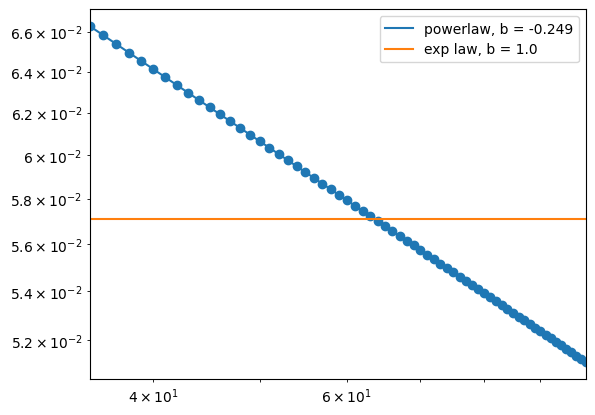

[2.24063773e-07 3.36604012e-07]
[inf inf inf]


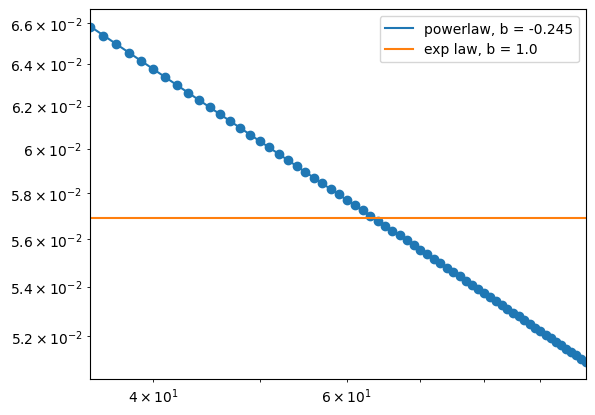

[4.49201307e-05 6.89124958e-05]
[inf inf inf]


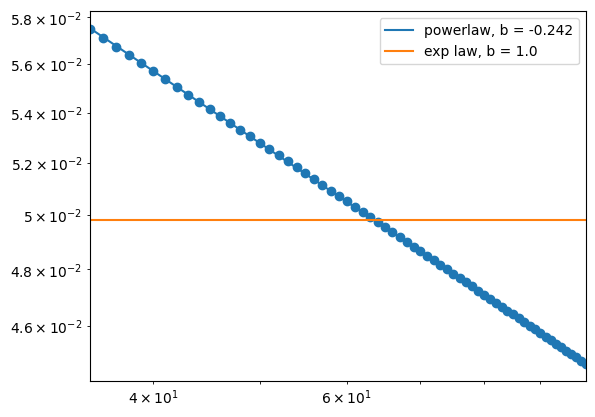

[7.20013758e-05 1.28162162e-04]
[inf inf inf]


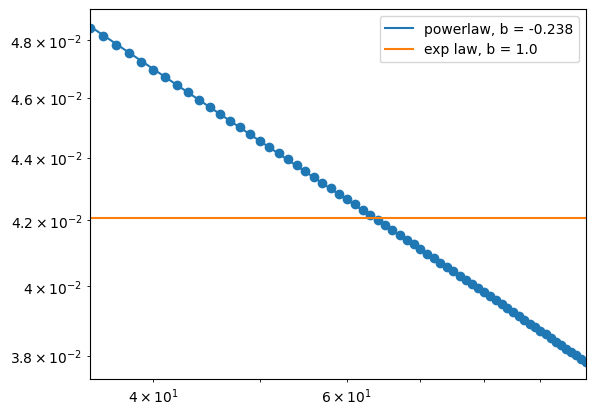

[8.40113924e-05 1.79625242e-04]
[inf inf inf]


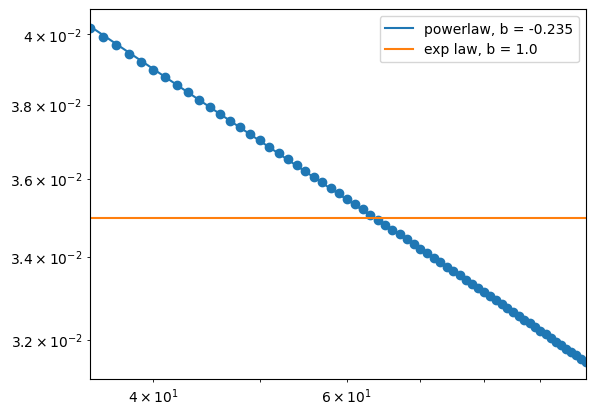

[8.61351157e-05 2.24549877e-04]
[inf inf inf]


In [128]:
x= np.arange(5,100,dtype=int)

y= [fit(data[0,30:],x[30:])[0][1]]
y+=[fit(data[1,30:],x[30:])[0][1]]
y+=[fit(data[2,30:],x[30:])[0][1]]
y+=[fit(data[3,30:],x[30:])[0][1]]
y+=[fit(data[4,30:],x[30:])[0][1]]


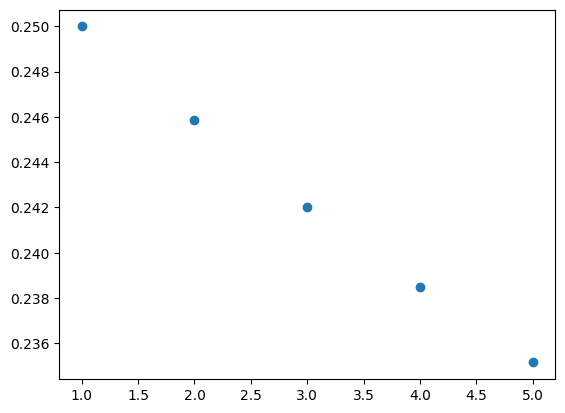

In [133]:
plt.scatter([1,2,3,4,5],-np.array(y))

In [43]:
#Params
L = 1000
J = 1
g = 1
k = kb.k_vals(L)
U = kb.U(k,g)
x= np.arange(0,50,dtype=int)

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)


Text(0.5, 0, 'r')

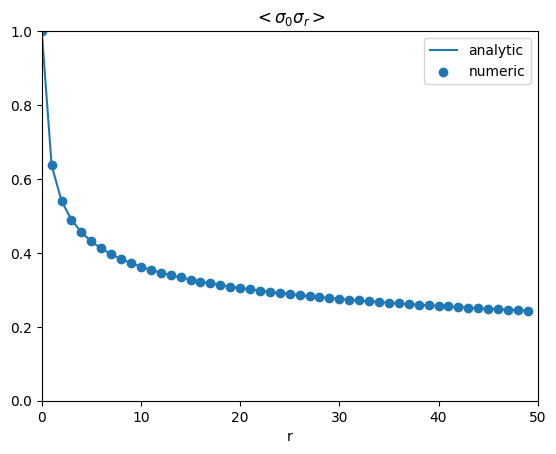

In [44]:
data_analytic = [sigma_general([0,xi]) for xi in x]
data_numeric =  [kb.sigma_general([0,xi],U,k) for xi in x ]
plot(x,data_analytic,label="analytic")
plt.scatter(x,data_numeric, label= "numeric")
plt.legend()
plt.xlim(0,50)
plt.ylim(0,1)
plt.title(r"$<\sigma_0 \sigma_r>$")

plt.xlabel("r")

Text(0.5, 0, 'r')

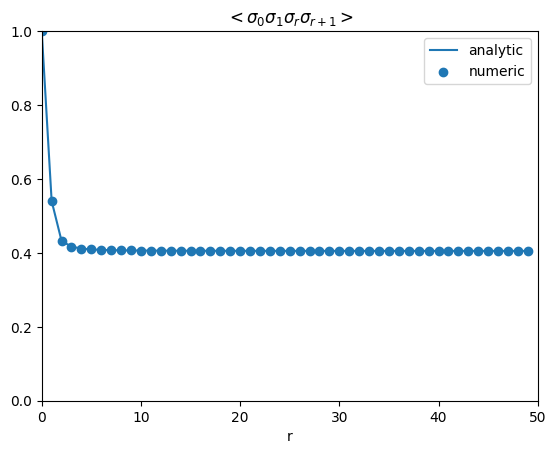

In [37]:
data_analytic = [sigma_general_exact([0,1,xi,xi+1]) for xi in x]
data_numeric =  [kb.sigma_general([0,1,xi,xi+1],U,k) for xi in x ]
plot(x,data_analytic,label="analytic")
plt.scatter(x,data_numeric, label= "numeric")
plt.legend()
plt.xlim(0,50)
plt.ylim(0,1)
plt.title(r"$<\sigma_0 \sigma_1 \sigma_r \sigma_{r+1}>$")
plt.xlabel("r")

Text(0.5, 0, 'r')

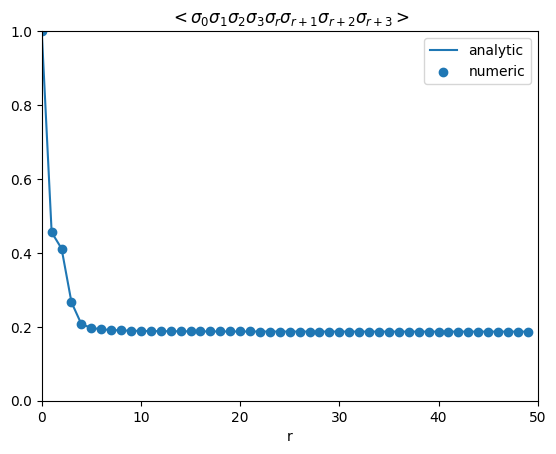

In [38]:
data_analytic = [sigma_general_exact([0,1,2,3,xi,xi+1,xi+2,xi+3]) for xi in x]
data_numeric =  [kb.sigma_general([0,1,2,3,xi,xi+1,xi+2,xi+3],U,k) for xi in x ]
plot(x,data_analytic,label="analytic")
plt.scatter(x,data_numeric, label= "numeric")
plt.legend()
plt.xlim(0,50)
plt.ylim(0,1)
plt.title(r"$<\sigma_0 \sigma_1 \sigma_2 \sigma_3 \sigma_r \sigma_{r+1} \sigma_{r+2} \sigma_{r+3}>$")
plt.xlabel("r")

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)


Text(0.5, 0, 'r')

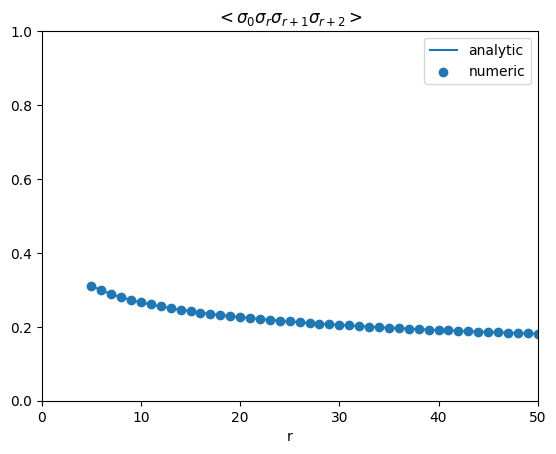

In [148]:
data_analytic = [sigma_general([0,xi,xi+1,xi+2]) for xi in x]
data_numeric =  [kb.sigma_general([0,xi,xi+1,xi+2],U,k) for xi in x ]
plot(x,data_analytic,label="analytic")
plt.scatter(x,data_numeric, label= "numeric")
plt.legend()
plt.xlim(0,50)
plt.ylim(0,1)
plt.title(r"$<\sigma_0  \sigma_r \sigma_{r+1} \sigma_{r+2} >$")
plt.xlabel("r")

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_31075/1714867528.py:5: RuntimeWarning: overflow encountered in exp
  return A*np.exp(-B*x)+C
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_31075/1714867528.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


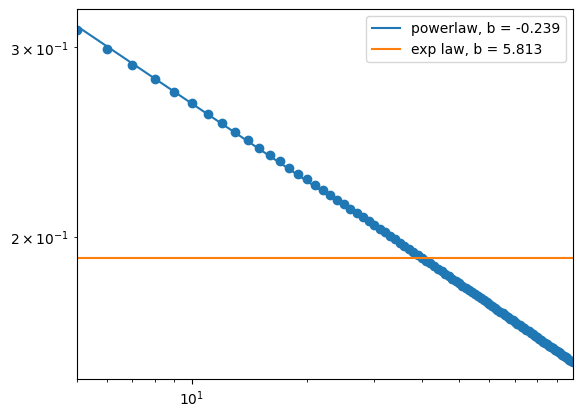

[0.00060649 0.0003696 ]
[inf inf inf]


(array([ 0.46196427, -0.23964082]),
 array([-20.10253022,   5.81316732,   0.19122738]))

In [143]:
def contributor_terms(n,l, even = True):
    #Term 1 
    indices = [i for i in range(0,n)]
    #Term 2 
    indices +=[i for i in range(n+l-1,2*n+l-1)]
    terms = kb.all_combinations(indices)
   # print(terms)
     ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

        # Filter only even-length vectors
    filtered = [(v, c) for v, c in zip(vecs, counts) if len(v) % 2 == 0]

    if filtered:
        vecs, counts = zip(*filtered)
        return list(vecs), np.array(counts)
    else:
        return [], np.array([])



In [147]:
contributor_terms(3,5)

([(np.int64(0), np.int64(1)),
  (np.int64(0), np.int64(2)),
  (np.int64(0), np.int64(7)),
  (np.int64(0), np.int64(8)),
  (np.int64(0), np.int64(9)),
  (np.int64(0), np.int64(6)),
  (np.int64(0), np.int64(5)),
  (np.int64(0), np.int64(1), np.int64(2), np.int64(7)),
  (np.int64(0), np.int64(1), np.int64(2), np.int64(8)),
  (np.int64(0), np.int64(1), np.int64(2), np.int64(9)),
  (np.int64(0), np.int64(1), np.int64(7), np.int64(8)),
  (np.int64(0), np.int64(1), np.int64(7), np.int64(9)),
  (np.int64(0), np.int64(1), np.int64(8), np.int64(9)),
  (np.int64(0), np.int64(2), np.int64(7), np.int64(8)),
  (np.int64(0), np.int64(2), np.int64(7), np.int64(9)),
  (np.int64(0), np.int64(2), np.int64(8), np.int64(9)),
  (np.int64(0), np.int64(7), np.int64(8), np.int64(9)),
  (np.int64(0), np.int64(1), np.int64(6), np.int64(7)),
  (np.int64(0), np.int64(1), np.int64(6), np.int64(8)),
  (np.int64(0), np.int64(6), np.int64(7), np.int64(8)),
  (np.int64(0), np.int64(5), np.int64(6), np.int64(7)),
  (np.

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_31075/1714867528.py:5: RuntimeWarning: overflow encountered in exp
  return A*np.exp(-B*x)+C
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_31075/1714867528.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


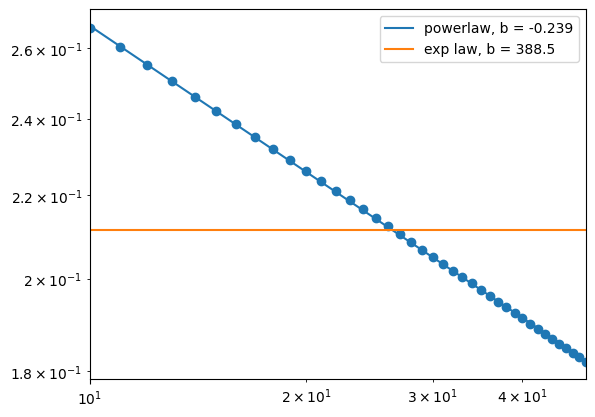

[0.00045795 0.00030621]
[inf inf inf]


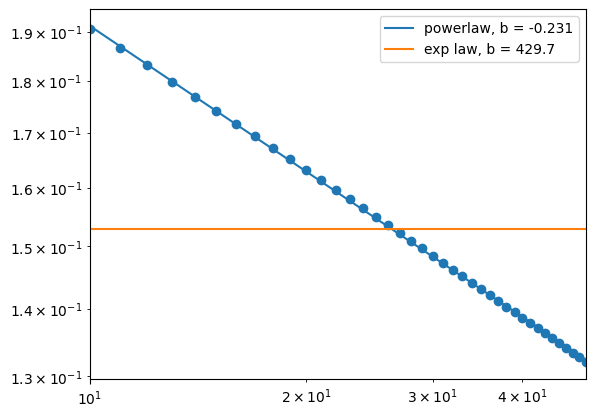

[0.00053876 0.0005118 ]
[inf inf inf]


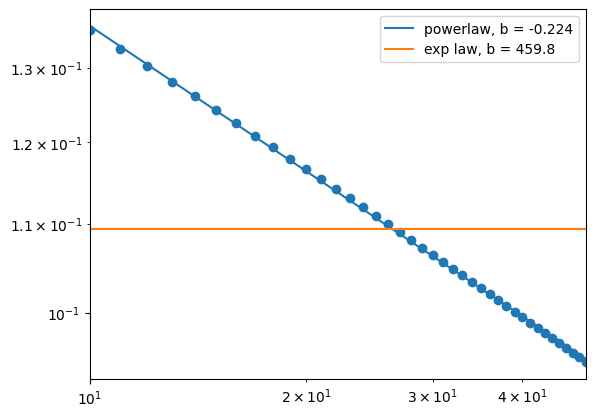

[0.0004828  0.00065508]
[inf inf inf]


(array([ 0.2278791 , -0.22434184]),
 array([-4.27821340e+03,  4.59870655e+02,  1.09387706e-01]))

In [151]:
x= np.arange(10,50)
data_analytic = [sigma_general([0,xi,xi+1,xi+2]) for xi in x]

fit(data_analytic,x)

data_analytic = [sigma_general([0,xi,xi+1,xi+2,xi+3,xi+4]) for xi in x]

fit(data_analytic,x)

data_analytic = [sigma_general([0,xi,xi+1,xi+2,xi+3,xi+4,xi+5,xi+6]) for xi in x]
fit(data_analytic,x)



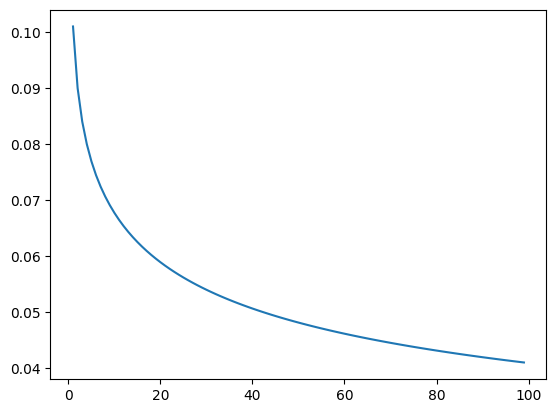

In [180]:
x= np.arange(1,100)
data_analytic = [sigma_general([0,xi,xi+1,xi+2,xi+3,xi+4,xi+5,xi+6,xi+7,xi+8,xi+9,xi+10]) for xi in x]

plot(x,data_analytic)
#fit(data_analytic,x)


In [160]:
import numpy as np


N = 20
x_coords = np.arange(0, N)

def compute_data_analytic(r_vals):
    results = []
    for r in r_vals:
        y_coords = np.arange(r, r + N)
        total = 0.0
        for xi in x_coords:
            for yi in y_coords:
                total += sigma_general([xi, xi + 1, yi, yi + 1])
        results.append(total)
    return np.array(results)

r_vals = np.arange(50, 500)
data_analytic = compute_data_analytic(r_vals)


In [164]:
data_analytic[-1]

np.float64(162.11405672275072)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_38170/1714867528.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


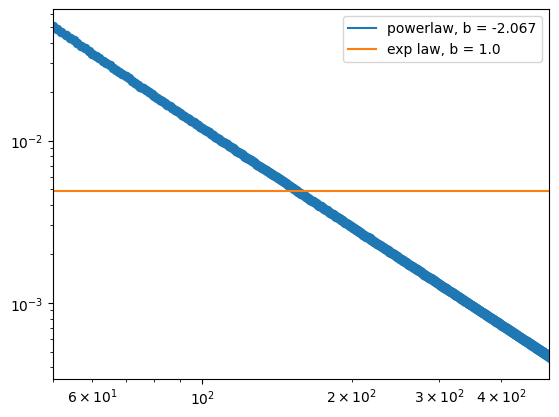

[0.93771721 0.00135235]
[inf inf inf]


(array([163.8863676 ,  -2.06770283]),
 array([1.        , 1.        , 0.00487801]))

In [145]:
fit(data_analytic,r_vals)

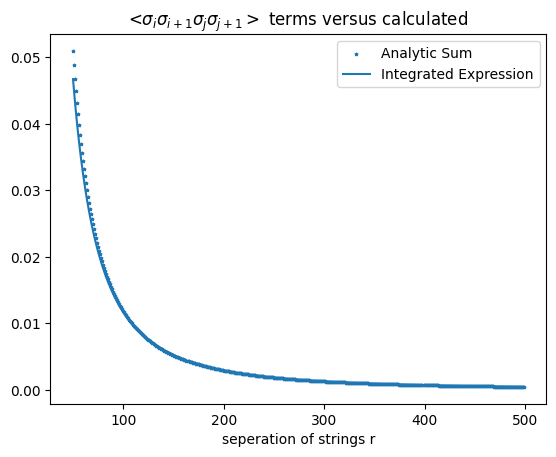

In [154]:

plt.scatter(r_vals,data_analytic,s=4,marker="*",label="Analytic Sum")
plt.plot(r_vals,(N)**2*256/np.pi**(4)/9/(r_vals**2),label= "Integrated Expression")
#plt.yscale("log")
#plt.xscale("log")
plt.title(r"<$\sigma_i \sigma_{i+1} \sigma_{j} \sigma_{j+1}>$ terms versus calculated")
plt.xlabel("seperation of strings r")
plt.legend()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_38170/1714867528.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


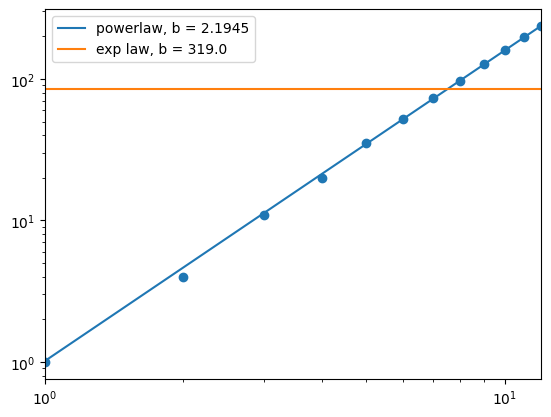

[0.03052466 0.01281172]
[inf inf inf]


(array([1.01610426, 2.19456086]),
 array([ 23.54866695, 319.09524877,  84.33333325]))

In [158]:
n_dat = np.array([1, 2, 3, 4, 5, 6, 7, 8,9,10,11,12])
x_dat =np.array( [1, 4, 11,20,35,52,73,96,127,160,197,236])

fit(x_dat,n_dat)


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


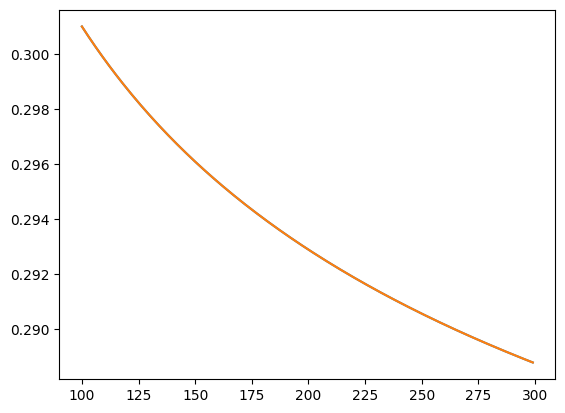

In [34]:
#Checking P1 P1 explicitly

X= np.arange(100,300)

y1 = np.array([sigma_general([0,xi]) for xi in X])

y_control = np.array([P_n_correlations(1,xi) for xi in X])

plot(X,(1+y1)/4)
plot(X,y_control)


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_47960/1714867528.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


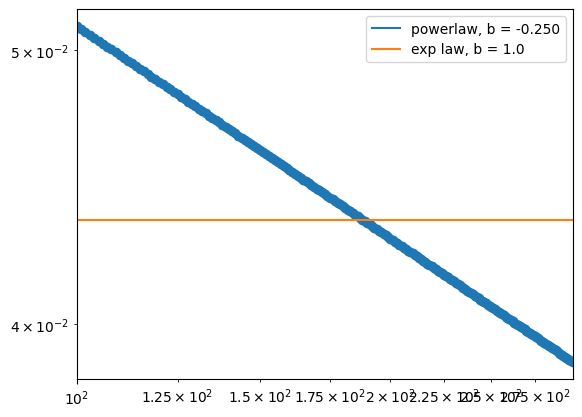

[2.08696119e-07 2.48344307e-07]
[inf inf inf]


(array([ 0.16126304, -0.25001339]),
 array([1.        , 1.        , 0.04352731]))

In [47]:
#Checking P2 P2 explicitly

X= np.arange(100,300)

y1 = np.array([sigma_general([0,xi]) for xi in X])
y2 = np.array([sigma_general([0,xi+1]) for xi in X])
y3 = np.array([sigma_general([1,xi]) for xi in X])
y4 = np.array([sigma_general([1,xi+1]) for xi in X])
y5 = np.array([sigma_general([0,1,xi,xi+1])-sigma_general([0,1])**2 for xi in X])


y_control = np.array([P_n_correlations(2,xi)-P_n(2)**2 for xi in X])

fit((y1+y2+y3+y4+y5)/16,X)


In [68]:
#Checking P3 P3 explicitly

X= np.arange(100,300)

y1 = np.array([sigma_general([0,xi]) for xi in X])
y2 = np.array([sigma_general([0,xi+1]) for xi in X])
y3 = np.array([sigma_general([0,xi+2]) for xi in X])

print("okay")

y4 = np.array([sigma_general([1,xi]) for xi in X])
y5 = np.array([sigma_general([1,xi+1]) for xi in X])
y6 = np.array([sigma_general([1,xi+2]) for xi in X])
print("okay")

y7 = np.array([sigma_general([2,xi]) for xi in X])
y8 = np.array([sigma_general([2,xi+1]) for xi in X])
y9 = np.array([sigma_general([2,xi+2]) for xi in X])
print("okay")

y10 = np.array([sigma_general([0,1,xi,xi+1])-sigma_general([0,1])**2 for xi in X])
y11 = np.array([sigma_general([0,1,xi,xi+2])-sigma_general([0,1])*sigma_general([0,2]) for xi in X])
y12 = np.array([sigma_general([0,1,xi+1,xi+2])-sigma_general([0,1])*sigma_general([1,2]) for xi in X])
print("okay")

y13 = np.array([sigma_general([0,2,xi,xi+1])-sigma_general([0,2])*sigma_general([0,1]) for xi in X])
y14 = np.array([sigma_general([0,2,xi,xi+2])-sigma_general([0,2])*sigma_general([0,2]) for xi in X])
y15 = np.array([sigma_general([0,2,xi+1,xi+2])-sigma_general([0,2])*sigma_general([1,2]) for xi in X])
print("okay")
y16 = np.array([sigma_general([1,2,xi,xi+1])-sigma_general([1,2])*sigma_general([0,1]) for xi in X])
y17 = np.array([sigma_general([1,2,xi,xi+2])-sigma_general([1,2])*sigma_general([0,2]) for xi in X])
y18 = np.array([sigma_general([1,2,xi+1,xi+2])-sigma_general([1,2])*sigma_general([1,2]) for xi in X])
print("okay")
y19 = np.array([sigma_general([0,1,2,xi,xi+1,xi+2]) for xi in X])

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


okay
okay
okay
okay
okay
okay


In [70]:
#"Weird" terms

w1 = np.array([sigma_general([0,xi,xi+1,xi+2]) for xi in X])
w2 = np.array([sigma_general([1,xi,xi+1,xi+2]) for xi in X])
w3 = np.array([sigma_general([2,xi,xi+1,xi+2]) for xi in X])
print("Okay")
w4 = np.array([sigma_general([0,1,2,xi]) for xi in X])
w5 = np.array([sigma_general([0,1,2,xi]) for xi in X])
w6 = np.array([sigma_general([0,1,2,xi]) for xi in X])


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Okay


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_47960/1714867528.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


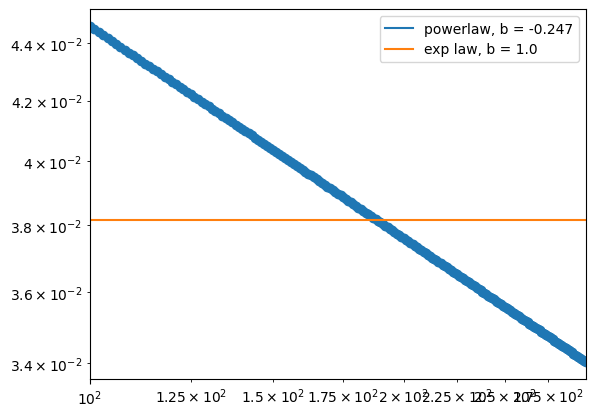

[2.03568620e-05 2.80507209e-05]
[inf inf inf]


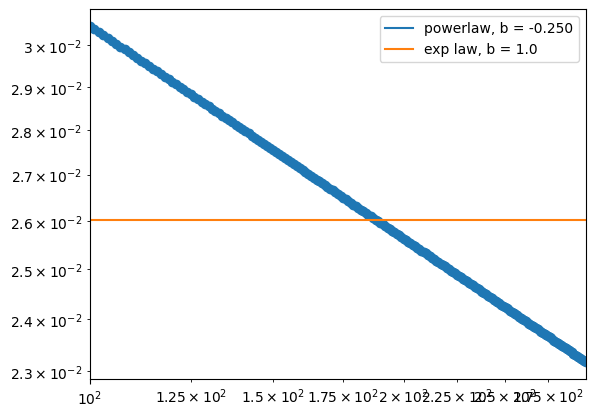

[6.04923082e-07 1.20408739e-06]
[inf inf inf]


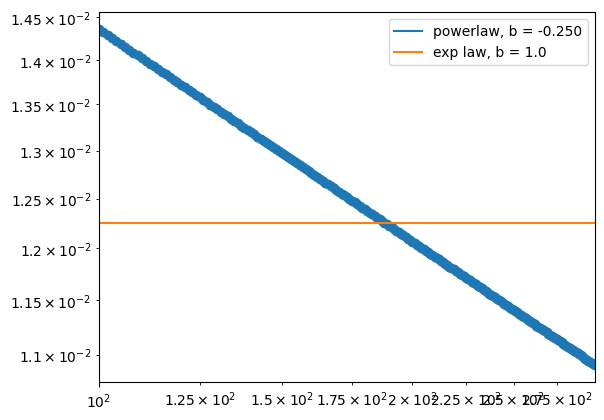

[1.88791251e-06 7.95139345e-06]
[inf inf inf]


(array([ 0.04556439, -0.25075761]),
 array([1.        , 1.        , 0.01225077]))

In [73]:
fit(y_control,X)
fit(1/64*(y1+y2+y3+y4+y5+y6+y7+y8+y9+y10+y11+y12+y13+y14+y15+y16+y17+y18+y19),X)
fit(1/64*(w1+w2+w3+w4+w5+w6),X)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_47960/1714867528.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


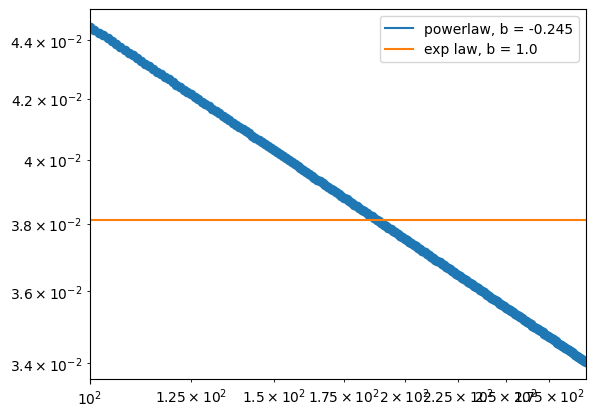

[3.02584063e-05 4.20788410e-05]
[inf inf inf]


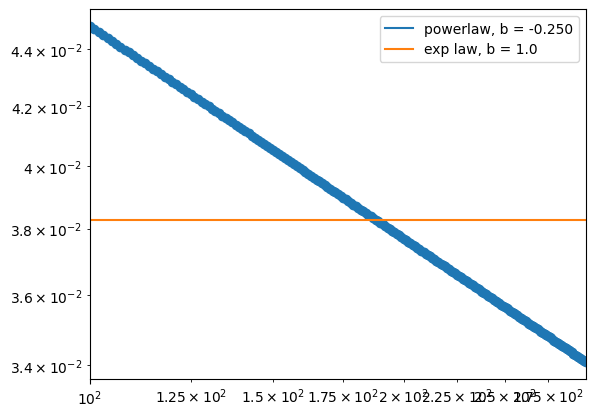

[2.48870554e-06 3.36392485e-06]
[inf inf inf]


(array([ 0.14197322, -0.25028734]),
 array([1.        , 1.        , 0.03826588]))

In [81]:
fit(y_control[1:],X[:-1])
fit(1/64*(y1+y2+y3+y4+y5+y6+y7+y8+y9+y10+y11+y12+y13+y14+y15+y16+y17+y18+y19)+1/64*(w1+w2+w3+w4+w5+w6),X)
#plot(X,1/64*(w1+w2+w3+w4+w5+w6))

In [93]:
(1/64*(y1+y2+y3+y4+y5+y6+y7+y8+y9+y10+y11+y12+y13+y14+y15+y16+y17+y18+y19)+1/64*(w1+w2+w3+w4+w5+w6))[2:7]-y_control[0:5]


array([1.75286216e-05, 1.73157284e-05, 1.71074455e-05, 1.69036299e-05,
       1.67041445e-05])

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_47960/1714867528.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


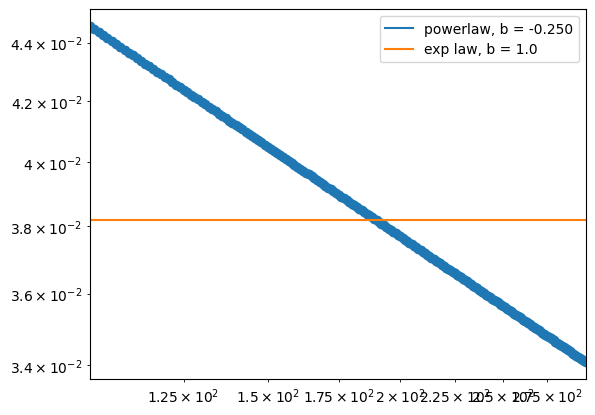

[6.99362721e-07 9.45267357e-07]
[inf inf inf]


(array([ 0.14176632, -0.2500516 ]),
 array([1.        , 1.        , 0.03819149]))

In [94]:
fit(y_control[:-2],X[2:])

In [98]:
n= 3

l= 5
indices = [i for i in range(0,n)]
    #Term 2 
indices +=[i for i in range(n+l-1,2*n+l-1)]

print(indices)

[0, 1, 2, 7, 8, 9]


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_47960/1714867528.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


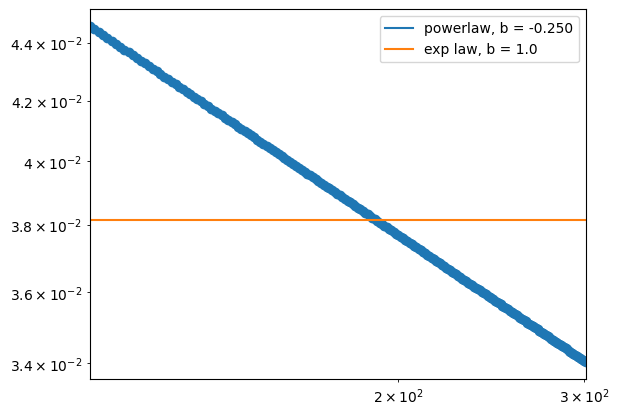

[6.96891857e-07 9.41202417e-07]
[inf inf inf]


(array([ 0.14176612, -0.25005133]),
 array([1.        , 1.        , 0.03814997]))

In [101]:
fit(y_control,X+2)

In [112]:
y_control = np.array([P_n_correlations(6,xi)-P_n(6)**2 for xi in X])


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_47960/1714867528.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


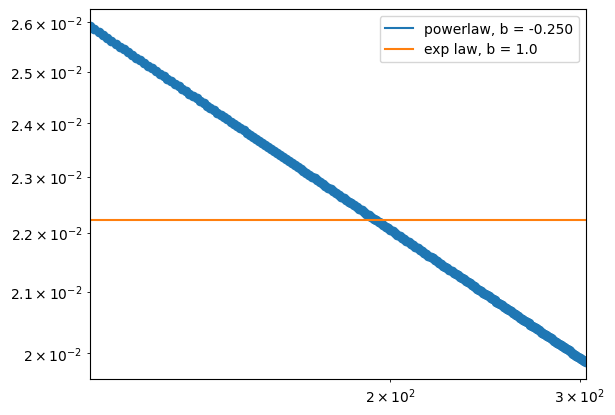

[2.27271032e-06 5.22091018e-06]
[inf inf inf]


(array([ 0.08306977, -0.25028916]),
 array([1.        , 1.        , 0.02223421]))

In [113]:

fit(y_control,X+5)
